# Week 3 - Predicting Default Probability

This notebook carries out the following steps
  1.  Reads the original data including all the fields added by Lending Club to predict default probability
  2. Redo the prediction using only the fields available in our saved pickle file
  3. Start with predicting default using only signals such as the grade or interest assigned to a loan by Lending Club
  4. Redo the analysis only with variables available at the time of loan application
  
Things for you to do
- Variable Selection for Tree and Logistic Regression Models
- Tuning the Tree Model for Performance and Explanation
- Tuning the Logistic Regression for Performance and Explanation
- Model Comparison (Think about how you might choose one of these classifiers for downstream analysis of picking out the best loans to invest in. Will you use a batch, rank-ordered or customized assessment method to pick between these models? How much do you care about the interpretability of the chosen model in this decision?)
- Optional: Try other models for prediction while answering the same questions as above (feature selection, tuning, explainability)
- Optional: You may compare the default probabilities predicted from Step 4 above with the grades assigned by Lending Club to see if they capture the same signal as your models

Prepare your presentation. Your presentation should contain at most 6 slides. Add an extra slide at the end if you tried the BONUS.

1.  Begin by stating the objective of the presentation and what your objective is. Which questions do you seek to answer? What are the main points of the presentation?
2. Feature engineering: Describe the results you got when there is data leakage. What is the final set of variables that you use? Did you generate your own variables? If so, explain what these variables capture.
3. (4.) Provide an intuitive explanation of at least two predictive models tried. How do you think they are determining if a loan will default or not? Do these results help you better understand the problem or the data? Compare the results of the models in the context of their use in the investment problem. Which metric did you use to compare them and why? For the logistic regression, start with the ouput model data and rank the significant coeffs in decreasing order of importance
5. State your conclusions. What is the main idea you wish to convey with the presentation? Do you think the findingsfrom this script will be useful to solve the overall problem? What are the main takeaways of the analysis you performed?

BONUS

- Can you improve your models using the results from module 2? If so, clearly state the improvements in terms of the metric you used to evaluate your models.

- Can you derive new variables from the original ones to improve your models? If so, clearly state the improvements in terms of the metric you used to evaluate your models.

- Use a more sophisticated (although less interpretable) predictive model such as tree boosting or support vector machine to obtain new results. Do these models perform better?

- Are there any exogenous variables (i.e. variables from other data sets, such as economic growth of the country) you might use to improve your models?



## Step 1 - Load the raw data again and predict default from all available fields

In [1]:
# Load general utilities
# ----------------------
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import numpy as np
import pickle
import time
import seaborn as sns
import os

# Load sklearn utilities
# ----------------------
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, brier_score_loss, mean_squared_error, r2_score

from sklearn.calibration import calibration_curve

# Load classifiers
# ----------------
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegressionCV

# Load debugger, if required
#import pixiedust
pd.options.mode.chained_assignment = None #'warn'

In [2]:
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

### Read downloaded file(s) again

In [3]:
## If you are re-running the script again and want to load all the models you have computed already and stored
# reload them from a saved dill file by uncommenting the next two lines and using the appropriate dill file name
# import dill
# dill.load_session('finalweek3.pkl')

## Reading Original files Input to Week 1

In [4]:
# load the data from the file
directory = '/Users/hrishikeshharishkumar/Desktop/Data/'
all_files = os.listdir(directory)
output = {}
for i in all_files:
    print("    Reading file " + i)
    output[i] = pd.read_csv(directory + i, dtype = str, skiprows = 1)

    Reading file LoanStats3b.csv.zip
    Reading file LoanStats3c.csv.zip


In [5]:
data = pd.concat([output[i] for i in output.keys()], join='inner')

In [6]:

data = data[['id','loan_amnt','funded_amnt','funded_amnt_inv','term','int_rate',
         'installment','grade','sub_grade','emp_title','emp_length',
         'home_ownership','annual_inc','verification_status','issue_d',
         'loan_status','purpose','title','zip_code','addr_state','dti','total_pymnt',
         'delinq_2yrs','earliest_cr_line','open_acc','pub_rec','last_pymnt_d',
         'last_pymnt_amnt','application_type','revol_bal','revol_util','recoveries']]

data.dropna(subset=['annual_inc','loan_status','issue_d','last_pymnt_d','loan_amnt',
                    'int_rate','earliest_cr_line','open_acc','pub_rec','delinq_2yrs',
                    'recoveries','grade','installment','funded_amnt','dti','funded_amnt_inv',
                    'revol_bal','revol_util']
            ,inplace=True)
data.shape

(423211, 32)

In [7]:
# Identify the type of each of these column
float_cols = ['loan_amnt', 'funded_amnt', 'installment', 'annual_inc',
            'dti', 'revol_bal', 'delinq_2yrs', 'open_acc', 'pub_rec', 'total_pymnt', 'recoveries']
cat_cols = ['term', 'grade', 'emp_length', 'home_ownership',
                    'verification_status', 'loan_status', 'purpose']
perc_cols = ['int_rate', 'revol_util']
date_cols = ['issue_d', 'earliest_cr_line', 'last_pymnt_d']

for j in float_cols:
    data[j] = pd.to_numeric(data[j])
    
for j in perc_cols:
    data[j] = data[j].str.strip('%')
    data[j] = pd.to_numeric(data[j])
    data[j] = data[j]/100

for j in date_cols:
    data[j] = pd.to_datetime(data[j])

In [8]:
data.shape

(423211, 32)

### Engineer the features and generate the training/testing set

In [9]:
data.loan_status.value_counts()

Fully Paid            193902
Current               172978
Charged Off            46493
Late (31-120 days)      5116
In Grace Period         3510
Late (16-30 days)       1102
Default                  110
Name: loan_status, dtype: int64

In [10]:
default_seed = 1
np.random.seed(default_seed)

# select only terminated loans
data = data[data.loan_status.isin(['Fully Paid','Charged Off','Default'])]

# downsample
data = data.sample(n=5000)

# create labels for the dataset
data['label'] = (data.loan_status.str.contains('Charged Off') | 
                data.loan_status.str.contains('Default'))
data['cr_hist'] = (data.issue_d - data.earliest_cr_line) / np.timedelta64(1, 'M')
data.label = data.label.astype(int)

In [11]:
data.shape

(5000, 34)

In [12]:
# clean and get training/testing data 
temp = pd.get_dummies(data[['term','grade','emp_length','home_ownership',
                                  'verification_status','purpose']],dummy_na=True)
subdata = data[['loan_amnt','funded_amnt','int_rate','installment',
                'annual_inc','dti','delinq_2yrs','open_acc','pub_rec', 'cr_hist','revol_bal',
                            'recoveries', 'revol_util', 'total_pymnt']]


In [13]:
X = subdata.to_numpy()
#X = data.as_matrix(columns=['loan_amnt','funded_amnt','int_rate','installment',
#                            'annual_inc','dti','delinq_2yrs','open_acc','pub_rec',
#                            'cr_hist','revol_bal',
#                            'recoveries',
#                            'revol_util', 'total_pymnt'])

#X = np.concatenate((X,temp.as_matrix()),axis=1)
X = np.concatenate((X,temp.to_numpy()),axis=1)

#y = data.label.as_matrix()
y = data.label.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

min_max_scaler = preprocessing.MinMaxScaler()
X_train = min_max_scaler.fit_transform(X_train)
X_test = min_max_scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(3500, 61)
(1500, 61)


In [36]:
#x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, random_state=0)

#logreg = LogisticRegression().fit(X_train,y_train)
#logreg

#print("Training set score: {:.3f}".format(logreg.score(X_train,y_train)))
#print("Test set score: {:.3f}".format(logreg.score(X_test,y_test)))

#import statsmodels.api as sm
#logit_model=sm.Logit(y,X)
#result=logit_model.fit()
#print(result.summary())

## Classification models

### $l_2$ penalized logistic regression

In [40]:
logisticModel = LogisticRegressionCV(cv=10,penalty='l2',max_iter=2000)
logisticModel.fit(X_train,y_train)

LogisticRegressionCV(cv=10, max_iter=2000)

In [41]:
#logisticModel1 = LogisticRegressionCV(cv=10,penalty='l2',max_iter=2000).fit(X_train,y_train)
#logisticModel

In [42]:
#pd.DataFrame(zip(X_train.columns, logisticModel1.coef_))

In [43]:
logisticModel.coef_

array([[ 2.13515908e+01,  4.81117798e+01,  4.69798604e+00,
         5.52836116e+01, -8.68885845e+00,  1.46271653e+00,
         1.08066513e+00, -1.18215338e+00, -3.85761689e-01,
         1.31472237e-01,  4.38294905e+00,  4.67824148e+02,
         2.62466821e+00, -1.86809439e+02, -1.27541287e+00,
         9.85149268e-01,  0.00000000e+00,  4.03276055e+00,
         3.62126533e+00,  2.58720499e+00,  1.63516585e+00,
        -6.97086230e-01,  5.78300604e-01, -1.20478747e+01,
         0.00000000e+00,  1.56036308e-01, -3.56969004e-01,
         4.99589485e-01, -8.38184483e-01, -4.00387053e-01,
        -8.27014195e-01,  3.68203816e-01,  2.27361448e-01,
        -5.47218805e-01,  1.14821345e+00, -4.92617595e-02,
         3.29367189e-01,  7.02494174e-01, -3.45260447e+00,
         0.00000000e+00,  1.09878007e+00,  1.36106662e+00,
         0.00000000e+00,  4.38824211e-01, -4.43212559e-01,
        -2.85875257e-01,  0.00000000e+00, -1.43545456e+00,
        -2.69978706e-01, -1.15896660e-01,  1.05918099e+0

In [44]:
logisticModel.intercept_

array([-6.59448093])

In [45]:
y_pred = logisticModel.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))

accuracy:  0.9933333333333333
                    precision    recall  f1-score   support

Non-Defaulted Loan     0.9927    0.9992    0.9959      1225
    Defaulted Loan     0.9963    0.9673    0.9815       275

          accuracy                         0.9933      1500
         macro avg     0.9945    0.9832    0.9887      1500
      weighted avg     0.9934    0.9933    0.9933      1500

AUC:  0.9942025974025974


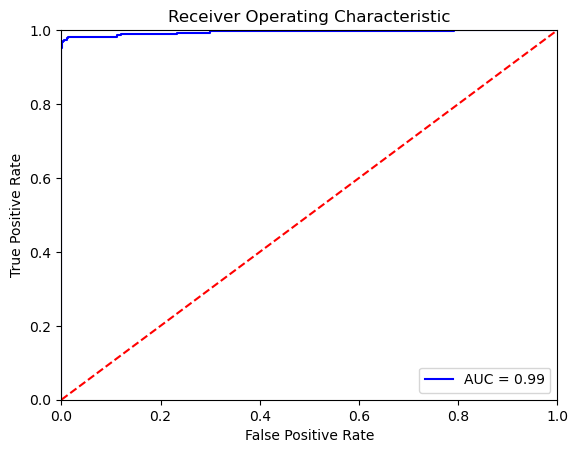

In [25]:
fpr, tpr, thresholds = roc_curve(y_test, logisticModel.predict_proba(X_test)[:,1],
                                         pos_label=1)
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b',
label='AUC = %0.2f'% roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

### Random forest
In addition to logistic regression, let's also take a quick look at random forest

In [26]:
random_forest = RandomForestClassifier(min_samples_leaf=100,n_estimators=50,random_state=123)
random_forest.fit(X_train,y_train)
y_pred = random_forest.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,random_forest.predict_proba(X_test)[:,1]))

accuracy:  0.9013333333333333
                    precision    recall  f1-score   support

Non-Defaulted Loan     0.8922    1.0000    0.9430      1225
    Defaulted Loan     1.0000    0.4618    0.6318       275

          accuracy                         0.9013      1500
         macro avg     0.9461    0.7309    0.7874      1500
      weighted avg     0.9120    0.9013    0.8860      1500

AUC:  0.9558441558441558


As we can see, with leaked features the AUC of the prediction models is ridiculously high

## Use statsmodel to run logit

# To decide which other variables we will have to discard to avoid signal leakage!

### a) Remove recoveries and total payment and verify the accuracy of both the models

In [20]:
# remove recoveries and total payment

In [21]:
data.shape

(5000, 34)

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 136824 to 209957
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   5000 non-null   object        
 1   loan_amnt            5000 non-null   int64         
 2   funded_amnt          5000 non-null   int64         
 3   funded_amnt_inv      5000 non-null   object        
 4   term                 5000 non-null   object        
 5   int_rate             5000 non-null   float64       
 6   installment          5000 non-null   float64       
 7   grade                5000 non-null   object        
 8   sub_grade            5000 non-null   object        
 9   emp_title            4688 non-null   object        
 10  emp_length           4756 non-null   object        
 11  home_ownership       5000 non-null   object        
 12  annual_inc           5000 non-null   float64       
 13  verification_status  5000 

In [23]:
# clean and get training/testing data 
temp = pd.get_dummies(data[['term','grade','emp_length','home_ownership',
                                  'verification_status','purpose']],dummy_na=True)
subdata = data[['loan_amnt','funded_amnt','int_rate','installment',
                'annual_inc','dti','delinq_2yrs','open_acc','pub_rec', 'cr_hist','revol_bal',
                            'revol_util']]   #'total_pymnt' ,  'recoveries',

In [24]:
X = subdata.to_numpy()
#X = data.as_matrix(columns=['loan_amnt','funded_amnt','int_rate','installment',
#                            'annual_inc','dti','delinq_2yrs','open_acc','pub_rec',
#                            'cr_hist','revol_bal',
#                            'recoveries',
#                            'revol_util', 'total_pymnt'])

#X = np.concatenate((X,temp.as_matrix()),axis=1)
X = np.concatenate((X,temp.to_numpy()),axis=1)

#y = data.label.as_matrix()
y = data.label.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

min_max_scaler = preprocessing.MinMaxScaler()
X_train = min_max_scaler.fit_transform(X_train)
X_test = min_max_scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(3500, 59)
(1500, 59)


In [25]:
logisticModel = LogisticRegressionCV(cv=10,penalty='l2',max_iter=2000)
logisticModel.fit(X_train,y_train)

LogisticRegressionCV(cv=10, max_iter=2000)

In [26]:
y_pred = logisticModel.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))

accuracy:  0.802
                    precision    recall  f1-score   support

Non-Defaulted Loan     0.8117    0.9835    0.8894      1214
    Defaulted Loan     0.3103    0.0315    0.0571       286

          accuracy                         0.8020      1500
         macro avg     0.5610    0.5075    0.4733      1500
      weighted avg     0.7161    0.8020    0.7307      1500

AUC:  0.705962488911418


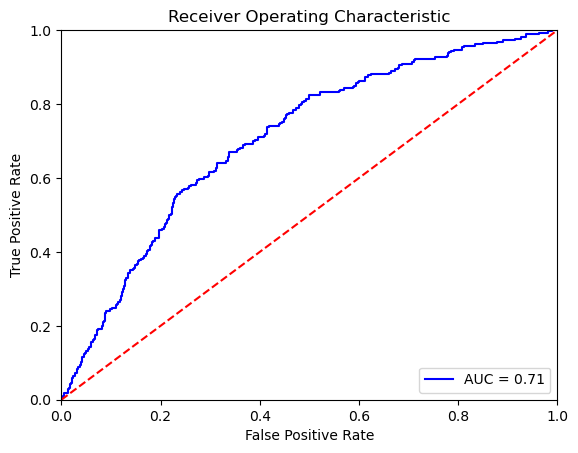

In [27]:
fpr, tpr, thresholds = roc_curve(y_test, logisticModel.predict_proba(X_test)[:,1],
                                         pos_label=1)
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b',
label='AUC = %0.2f'% roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [28]:
random_forest = RandomForestClassifier(min_samples_leaf=100,n_estimators=50,random_state=123)
random_forest.fit(X_train,y_train)
y_pred = random_forest.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,random_forest.predict_proba(X_test)[:,1]))

accuracy:  0.8093333333333333
                    precision    recall  f1-score   support

Non-Defaulted Loan     0.8093    1.0000    0.8946      1214
    Defaulted Loan     0.0000    0.0000    0.0000       286

          accuracy                         0.8093      1500
         macro avg     0.4047    0.5000    0.4473      1500
      weighted avg     0.6550    0.8093    0.7240      1500

AUC:  0.7046894621029711


## Remove other variables contributing to the leakage

In [29]:
# remove grade and interest rate

In [30]:
data.shape

(5000, 34)

In [31]:
# clean and get training/testing data 
temp = pd.get_dummies(data[['term','emp_length','home_ownership',
                                  'verification_status','purpose']],dummy_na=True) #'grade'
subdata = data[['loan_amnt','funded_amnt','installment',
                'annual_inc','dti','delinq_2yrs','open_acc','pub_rec', 'cr_hist','revol_bal',
                            'revol_util']]   #'total_pymnt' ,  'recoveries', 'int_rate',

In [32]:
X = subdata.to_numpy()
#X = data.as_matrix(columns=['loan_amnt','funded_amnt','int_rate','installment',
#                            'annual_inc','dti','delinq_2yrs','open_acc','pub_rec',
#                            'cr_hist','revol_bal',
#                            'recoveries',
#                            'revol_util', 'total_pymnt'])

#X = np.concatenate((X,temp.as_matrix()),axis=1)
X = np.concatenate((X,temp.to_numpy()),axis=1)

#y = data.label.as_matrix()
y = data.label.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

min_max_scaler = preprocessing.MinMaxScaler()
X_train = min_max_scaler.fit_transform(X_train)
X_test = min_max_scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(3500, 50)
(1500, 50)


In [33]:
logisticModel = LogisticRegressionCV(cv=10,penalty='l2',max_iter=2000,random_state=123)
logisticModel.fit(X_train,y_train)

LogisticRegressionCV(cv=10, max_iter=2000, random_state=123)

In [34]:
y_pred = logisticModel.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))

accuracy:  0.802
                    precision    recall  f1-score   support

Non-Defaulted Loan     0.8151    0.9769    0.8887      1214
    Defaulted Loan     0.3778    0.0594    0.1027       286

          accuracy                         0.8020      1500
         macro avg     0.5964    0.5182    0.4957      1500
      weighted avg     0.7317    0.8020    0.7389      1500

AUC:  0.6831516918007856


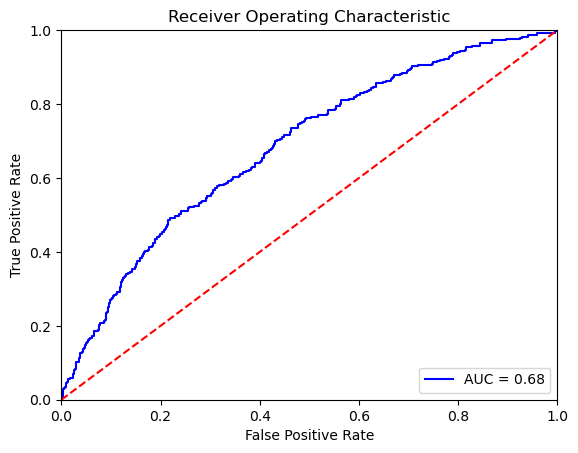

In [35]:
fpr, tpr, thresholds = roc_curve(y_test, logisticModel.predict_proba(X_test)[:,1],
                                         pos_label=1)
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b',
label='AUC = %0.2f'% roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [36]:
random_forest = RandomForestClassifier(min_samples_leaf=100,n_estimators=50,random_state=123)
random_forest.fit(X_train,y_train)
y_pred = random_forest.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,random_forest.predict_proba(X_test)[:,1]))

accuracy:  0.8093333333333333
                    precision    recall  f1-score   support

Non-Defaulted Loan     0.8093    1.0000    0.8946      1214
    Defaulted Loan     0.0000    0.0000    0.0000       286

          accuracy                         0.8093      1500
         macro avg     0.4047    0.5000    0.4473      1500
      weighted avg     0.6550    0.8093    0.7240      1500

AUC:  0.6874200758055784


# Step 2 - Redo predictions with the columns stored in our pickle file

In [37]:
# Load general utilities
# ----------------------
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.axes as ax
import datetime
import numpy as np
import pickle
import time
import seaborn as sns

# Load sklearn utilities
# ----------------------
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, brier_score_loss, mean_squared_error, r2_score

from sklearn.calibration import calibration_curve

# Load classifiers
# ----------------
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier

# Other Packages
# --------------
from scipy.stats import kendalltau
from sklearn.neural_network import MLPRegressor
from sklearn import linear_model
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
## from gurobipy import *
# from sklearn.externals.six import StringIO
from six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
!conda install -y pydotplus
import pydotplus
#from scipy.interpolate import spline

# Load debugger, if required
#import pixiedust
pd.options.mode.chained_assignment = None #'warn'

# suppress all warnings
import warnings
warnings.filterwarnings("ignore")

Solving environment: done


==> WARNING: A newer version of conda exists. <==
  current version: 23.3.1
  latest version: 23.7.4

Please update conda by running

    $ conda update -n base -c defaults conda

Or to minimize the number of packages updated during conda update use

     conda install conda=23.7.4



# All requested packages already installed.



In [38]:
# Define a function that, given a CVGridSearch object, finds the
# percentage difference between the best and worst scores
def find_score_variation(cv_model):
    all_scores = cv_model.cv_results_['mean_test_score']
    return( np.abs((max(all_scores) - min(all_scores))) * 100 / max(all_scores) )

    '''
    which_min_score = np.argmin(all_scores)

    all_perc_diff = []

    try:
        all_perc_diff.append( np.abs(all_scores[which_min_score - 1] - all_scores[which_min_score])*100 / min(all_scores) )
    except:
        pass

    try:
        all_perc_diff.append( np.abs(all_scores[which_min_score + 1] - all_scores[which_min_score])*100 / min(all_scores) )
    except:
        pass

    return ( np.mean(all_perc_diff) )
    '''

# Define a function that checks, given a CVGridSearch object,
# whether the optimal parameters lie on the edge of the search
# grid
def find_opt_params_on_edge(cv_model):
    out = False

    for i in cv_model.param_grid:
        if cv_model.best_params_[i] in [ cv_model.param_grid[i][0], cv_model.param_grid[i][-1] ]:
            out = True
            break

    return out

## Define a default random seed and an output file

In [39]:
default_seed = 1
output_file = "output_sample_hrishi"

In [40]:
# Create a function to print a line to our output file

def dump_to_output(key, value):
    with open(output_file, "a") as f:
        f.write(",".join([str(default_seed), key, str(value)]) + "\n")

## Load the data and engineer the features

In [41]:
# Read the data and features from the pickle
data, discrete_features, continuous_features, ret_cols = pickle.load( open( "/Users/hrishikeshharishkumar/CMU Mini 1 - Fall 2023 - Business Value through Integrative Analytics/Update 2: Diagnostic and Descriptive Analysis/PickleData/ret_data.pickle", "rb" ) )

#data, discrete_features, continuous_features, ret_cols = pickle.load( open( "/Users/hrishikeshharishkumar/Documents/CMU Tepper - MSBA/Mini 1 - Fall 2023/Business Value through Integrative Analytics/Update 3 - Predictive Modeling -Probability of Default/pickle", "rb" ) )

In [42]:
data.shape

(196527, 43)

In [43]:
data = data.drop(['zip_code','ret_PESS','ret_OPT','ret_INTa','ret_INTb','ret_INTc'], axis=1, errors='ignore')

In [44]:
discrete_features.remove('zip_code')

In [45]:
data.loan_status.value_counts()

Fully Paid     157817
Charged Off     38609
Default           101
Name: loan_status, dtype: int64

In [46]:
weights = {'Fully Paid' : 1, 'Charged Off' : 3, 'Default' : 2}

In [47]:
data['weights'] = data['loan_status'].apply(lambda x:weights[x])
#data

In [48]:
data = data.sample(n=5000, weights = 'weights', random_state =123)

In [49]:
default_seed = 1
np.random.seed(default_seed)

# select only terminated loans
#data = data[data.loan_status.isin(['Fully Paid','Charged Off','Default'])]

# downsample
#data = data.sample(n=5000, weights = 'default')

# create labels for the dataset
data['label'] = (data.loan_status.str.contains('Charged Off') | 
                data.loan_status.str.contains('Default'))
data['cr_hist'] = (data.issue_d - data.earliest_cr_line) / np.timedelta64(1, 'M')
data.label = data.label.astype(int)

In [50]:
data.shape

(5000, 40)

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 281969 to 145463
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   5000 non-null   object 
 1   loan_amnt            5000 non-null   float64
 2   funded_amnt          5000 non-null   float64
 3   term                 5000 non-null   object 
 4   int_rate             5000 non-null   float64
 5   installment          5000 non-null   float64
 6   grade                5000 non-null   object 
 7   emp_length           4746 non-null   object 
 8   home_ownership       5000 non-null   object 
 9   annual_inc           5000 non-null   float64
 10  verification_status  5000 non-null   object 
 11  issue_d              5000 non-null   object 
 12  loan_status          5000 non-null   object 
 13  purpose              5000 non-null   object 
 14  dti                  5000 non-null   float64
 15  delinq_2yrs          5000 non-n

In [53]:
#data.to_csv('data2.csv')

In [54]:
# clean and get training/testing data 
temp = pd.get_dummies(data[['term','grade','emp_length','home_ownership',
                                  'verification_status','purpose']],dummy_na=True)
subdata = data[['loan_amnt','funded_amnt','int_rate','installment',
                'annual_inc','dti','delinq_2yrs','open_acc','pub_rec', 'cr_hist','revol_bal',
                            'recoveries', 'revol_util', 'total_pymnt','out_prncp','tot_cur_bal','bc_util',
               'funded_amnt_inv', 'inq_last_6mths', 'pct_tl_nvr_dlq','total_acc','acc_now_delinq','tot_coll_amt',
               'default','loan_length']]

In [55]:
X = subdata.to_numpy()
#X = data.as_matrix(columns=['loan_amnt','funded_amnt','int_rate','installment',
#                            'annual_inc','dti','delinq_2yrs','open_acc','pub_rec',
#                            'cr_hist','revol_bal',
#                            'recoveries',
#                            'revol_util', 'total_pymnt'])

#X = np.concatenate((X,temp.as_matrix()),axis=1)
X = np.concatenate((X,temp.to_numpy()),axis=1)

#y = data.label.as_matrix()
y = data.label.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

min_max_scaler = preprocessing.MinMaxScaler()
X_train = min_max_scaler.fit_transform(X_train)
X_test = min_max_scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(3500, 71)
(1500, 71)


In [56]:
logisticModel = LogisticRegressionCV(cv=10,penalty='l2',max_iter=2000)
logisticModel.fit(X_train,y_train)

LogisticRegressionCV(cv=10, max_iter=2000)

In [57]:
y_pred = logisticModel.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))

accuracy:  1.0
                    precision    recall  f1-score   support

Non-Defaulted Loan     1.0000    1.0000    1.0000       880
    Defaulted Loan     1.0000    1.0000    1.0000       620

          accuracy                         1.0000      1500
         macro avg     1.0000    1.0000    1.0000      1500
      weighted avg     1.0000    1.0000    1.0000      1500

AUC:  1.0


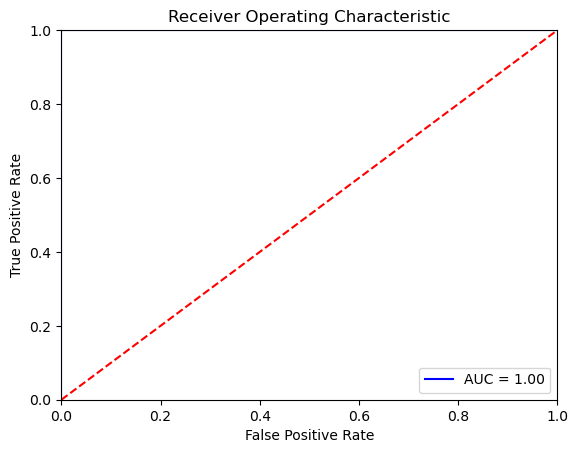

In [58]:
fpr, tpr, thresholds = roc_curve(y_test, logisticModel.predict_proba(X_test)[:,1],
                                         pos_label=1)
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b',
label='AUC = %0.2f'% roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [59]:
random_forest = RandomForestClassifier(min_samples_leaf=100,n_estimators=50,random_state=123)
random_forest.fit(X_train,y_train)
y_pred = random_forest.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,random_forest.predict_proba(X_test)[:,1]))

accuracy:  0.9786666666666667
                    precision    recall  f1-score   support

Non-Defaulted Loan     0.9649    1.0000    0.9821       880
    Defaulted Loan     1.0000    0.9484    0.9735       620

          accuracy                         0.9787      1500
         macro avg     0.9825    0.9742    0.9778      1500
      weighted avg     0.9794    0.9787    0.9786      1500

AUC:  0.9997928885630498


## Remove recoveries and total payment

In [60]:
data.shape

(5000, 40)

In [61]:
# clean and get training/testing data 
temp1 = pd.get_dummies(data[['term','grade','emp_length','home_ownership',
                                  'verification_status','purpose']],dummy_na=True)
subdata1 = data[['loan_amnt','funded_amnt','int_rate','installment',
                'annual_inc','dti','delinq_2yrs','open_acc','pub_rec', 'cr_hist','revol_bal',
                             'revol_util', 'out_prncp','tot_cur_bal','bc_util',
               'funded_amnt_inv', 'inq_last_6mths', 'pct_tl_nvr_dlq','total_acc','acc_now_delinq','tot_coll_amt',
               'default','loan_length']]   #recoveries , 'total_pymnt',

In [62]:
X = subdata1.to_numpy()
#X = data.as_matrix(columns=['loan_amnt','funded_amnt','int_rate','installment',
#                            'annual_inc','dti','delinq_2yrs','open_acc','pub_rec',
#                            'cr_hist','revol_bal',
#                            'recoveries',
#                            'revol_util', 'total_pymnt'])

#X = np.concatenate((X,temp.as_matrix()),axis=1)
X = np.concatenate((X,temp1.to_numpy()),axis=1)

#y = data.label.as_matrix()
y = data.label.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

min_max_scaler = preprocessing.MinMaxScaler()
X_train = min_max_scaler.fit_transform(X_train)
X_test = min_max_scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(3500, 69)
(1500, 69)


In [63]:
logisticModel = LogisticRegressionCV(cv=10,penalty='l2',max_iter=2000)
logisticModel.fit(X_train,y_train)

LogisticRegressionCV(cv=10, max_iter=2000)

In [64]:
y_pred = logisticModel.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))


accuracy:  1.0
                    precision    recall  f1-score   support

Non-Defaulted Loan     1.0000    1.0000    1.0000       881
    Defaulted Loan     1.0000    1.0000    1.0000       619

          accuracy                         1.0000      1500
         macro avg     1.0000    1.0000    1.0000      1500
      weighted avg     1.0000    1.0000    1.0000      1500

AUC:  1.0


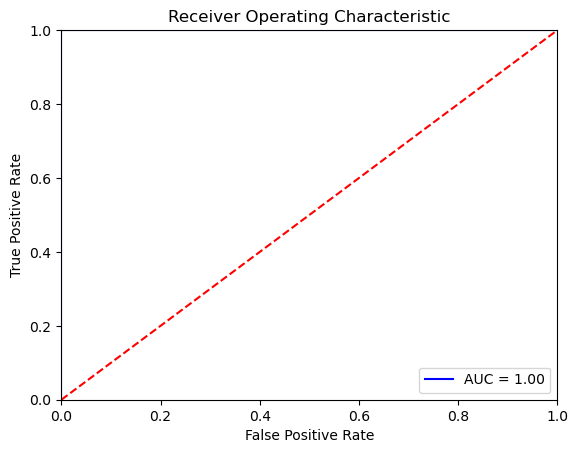

In [65]:
fpr, tpr, thresholds = roc_curve(y_test, logisticModel.predict_proba(X_test)[:,1],
                                         pos_label=1)
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b',
label='AUC = %0.2f'% roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()


In [66]:
random_forest = RandomForestClassifier(min_samples_leaf=100,n_estimators=50,random_state=123)
random_forest.fit(X_train,y_train)
y_pred = random_forest.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,random_forest.predict_proba(X_test)[:,1]))


accuracy:  0.9833333333333333
                    precision    recall  f1-score   support

Non-Defaulted Loan     0.9735    0.9989    0.9860       881
    Defaulted Loan     0.9983    0.9612    0.9794       619

          accuracy                         0.9833      1500
         macro avg     0.9859    0.9800    0.9827      1500
      weighted avg     0.9837    0.9833    0.9833      1500

AUC:  0.9995947474873428


## Remove default

In [67]:
data.shape

(5000, 40)

In [68]:
# clean and get training/testing data 
temp2 = pd.get_dummies(data[['term','grade','emp_length','home_ownership',
                                  'verification_status','purpose']],dummy_na=True)
subdata2 = data[['loan_amnt','funded_amnt','int_rate','installment',
                'annual_inc','dti','delinq_2yrs','open_acc','pub_rec', 'cr_hist','revol_bal',
                             'revol_util', 'out_prncp','tot_cur_bal','bc_util',
               'funded_amnt_inv', 'inq_last_6mths', 'pct_tl_nvr_dlq','total_acc','acc_now_delinq','tot_coll_amt'
               ,'loan_length']]   #recoveries , 'total_pymnt', 'default'

In [69]:
X = subdata2.to_numpy()
#X = data.as_matrix(columns=['loan_amnt','funded_amnt','int_rate','installment',
#                            'annual_inc','dti','delinq_2yrs','open_acc','pub_rec',
#                            'cr_hist','revol_bal',
#                            'recoveries',
#                            'revol_util', 'total_pymnt'])

#X = np.concatenate((X,temp.as_matrix()),axis=1)
X = np.concatenate((X,temp2.to_numpy()),axis=1)

#y = data.label.as_matrix()
y = data.label.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

min_max_scaler = preprocessing.MinMaxScaler()
X_train = min_max_scaler.fit_transform(X_train)
X_test = min_max_scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(3500, 68)
(1500, 68)


In [70]:
logisticModel = LogisticRegressionCV(cv=10,penalty='l2',max_iter=2000)
logisticModel.fit(X_train,y_train)

LogisticRegressionCV(cv=10, max_iter=2000)

In [71]:
y_pred = logisticModel.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))

accuracy:  0.698
                    precision    recall  f1-score   support

Non-Defaulted Loan     0.7095    0.8085    0.7558       867
    Defaulted Loan     0.6758    0.5466    0.6044       633

          accuracy                         0.6980      1500
         macro avg     0.6926    0.6776    0.6801      1500
      weighted avg     0.6953    0.6980    0.6919      1500

AUC:  0.7600230316083314


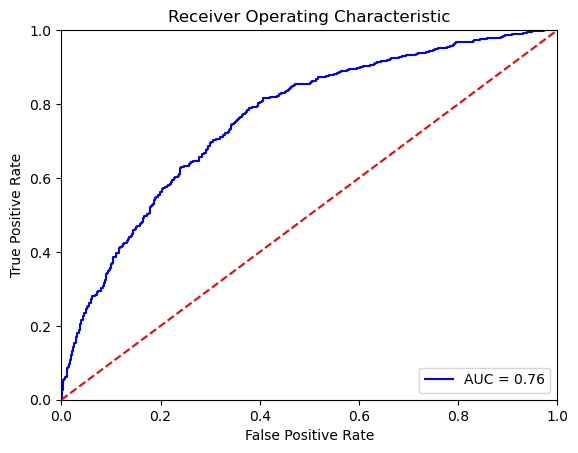

In [72]:
fpr, tpr, thresholds = roc_curve(y_test, logisticModel.predict_proba(X_test)[:,1],
                                         pos_label=1)
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b',
label='AUC = %0.2f'% roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()


In [73]:
random_forest = RandomForestClassifier(min_samples_leaf=100,n_estimators=50,random_state=123)
random_forest.fit(X_train,y_train)
y_pred = random_forest.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,random_forest.predict_proba(X_test)[:,1]))

accuracy:  0.678
                    precision    recall  f1-score   support

Non-Defaulted Loan     0.6784    0.8420    0.7514       867
    Defaulted Loan     0.6769    0.4534    0.5430       633

          accuracy                         0.6780      1500
         macro avg     0.6777    0.6477    0.6472      1500
      weighted avg     0.6778    0.6780    0.6635      1500

AUC:  0.751490039376033


## Remove grade and Interest rate

In [74]:
data.shape

(5000, 40)

In [75]:
# clean and get training/testing data 
temp3 = pd.get_dummies(data[['term','emp_length','home_ownership',
                                  'verification_status','purpose']],dummy_na=True)  #'grade',
subdata3 = data[['loan_amnt','funded_amnt','installment',
                'annual_inc','dti','delinq_2yrs','open_acc','pub_rec', 'cr_hist','revol_bal',
                             'revol_util', 'out_prncp','tot_cur_bal','bc_util',
               'funded_amnt_inv', 'inq_last_6mths', 'pct_tl_nvr_dlq','total_acc','acc_now_delinq','tot_coll_amt'
               ,'loan_length']]   #recoveries , 'total_pymnt', 'default' ,'int_rate'

In [76]:
X = subdata3.to_numpy()
#X = data.as_matrix(columns=['loan_amnt','funded_amnt','int_rate','installment',
#                            'annual_inc','dti','delinq_2yrs','open_acc','pub_rec',
#                            'cr_hist','revol_bal',
#                            'recoveries',
#                            'revol_util', 'total_pymnt'])

#X = np.concatenate((X,temp.as_matrix()),axis=1)
X = np.concatenate((X,temp3.to_numpy()),axis=1)

#y = data.label.as_matrix()
y = data.label.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

min_max_scaler = preprocessing.MinMaxScaler()
X_train = min_max_scaler.fit_transform(X_train)
X_test = min_max_scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(3500, 59)
(1500, 59)


In [77]:
logisticModel = LogisticRegressionCV(cv=10,penalty='l2',max_iter=2000)
logisticModel.fit(X_train,y_train)

LogisticRegressionCV(cv=10, max_iter=2000)

In [78]:
y_pred = logisticModel.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))

accuracy:  0.6853333333333333
                    precision    recall  f1-score   support

Non-Defaulted Loan     0.7141    0.7771    0.7443       884
    Defaulted Loan     0.6338    0.5536    0.5910       616

          accuracy                         0.6853      1500
         macro avg     0.6740    0.6654    0.6676      1500
      weighted avg     0.6812    0.6853    0.6813      1500

AUC:  0.7518290532996416


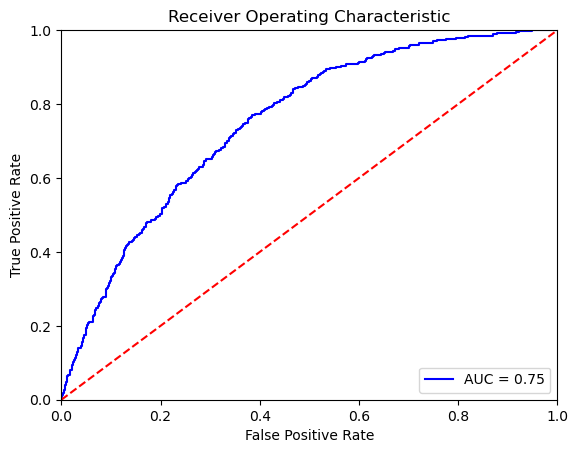

In [79]:
fpr, tpr, thresholds = roc_curve(y_test, logisticModel.predict_proba(X_test)[:,1],
                                         pos_label=1)
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b',
label='AUC = %0.2f'% roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [80]:
random_forest = RandomForestClassifier(min_samples_leaf=100,n_estimators=50,random_state=123)
random_forest.fit(X_train,y_train)
y_pred = random_forest.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,random_forest.predict_proba(X_test)[:,1]))

accuracy:  0.662
                    precision    recall  f1-score   support

Non-Defaulted Loan     0.6602    0.8790    0.7540       884
    Defaulted Loan     0.6687    0.3506    0.4601       616

          accuracy                         0.6620      1500
         macro avg     0.6644    0.6148    0.6070      1500
      weighted avg     0.6637    0.6620    0.6333      1500

AUC:  0.7463198566139742


## Remove funded amt inv

In [81]:
data.shape

(5000, 40)

In [82]:
# clean and get training/testing data 
temp4 = pd.get_dummies(data[['term','emp_length','home_ownership',
                                  'verification_status','purpose']],dummy_na=True)  #'grade',
subdata4 = data[['loan_amnt','funded_amnt','installment',
                'annual_inc','dti','delinq_2yrs','open_acc','pub_rec', 'cr_hist','revol_bal',
                             'revol_util', 'out_prncp','tot_cur_bal','bc_util',
                'inq_last_6mths', 'pct_tl_nvr_dlq','total_acc','acc_now_delinq','tot_coll_amt'
               ,'loan_length']]   #recoveries , 'total_pymnt', 'default' ,'int_rate', 'funded_amnt_inv',

In [83]:
X = subdata4.to_numpy()
#X = data.as_matrix(columns=['loan_amnt','funded_amnt','int_rate','installment',
#                            'annual_inc','dti','delinq_2yrs','open_acc','pub_rec',
#                            'cr_hist','revol_bal',
#                            'recoveries',
#                            'revol_util', 'total_pymnt'])

#X = np.concatenate((X,temp.as_matrix()),axis=1)
X = np.concatenate((X,temp4.to_numpy()),axis=1)

#y = data.label.as_matrix()
y = data.label.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

min_max_scaler = preprocessing.MinMaxScaler()
X_train = min_max_scaler.fit_transform(X_train)
X_test = min_max_scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(3500, 58)
(1500, 58)


In [84]:
logisticModel = LogisticRegressionCV(cv=10,penalty='l2',max_iter=2000)
logisticModel.fit(X_train,y_train)

LogisticRegressionCV(cv=10, max_iter=2000)

In [85]:
y_pred = logisticModel.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))


accuracy:  0.6906666666666667
                    precision    recall  f1-score   support

Non-Defaulted Loan     0.7039    0.7925    0.7456       858
    Defaulted Loan     0.6667    0.5545    0.6054       642

          accuracy                         0.6907      1500
         macro avg     0.6853    0.6735    0.6755      1500
      weighted avg     0.6880    0.6907    0.6856      1500

AUC:  0.7593693948834137


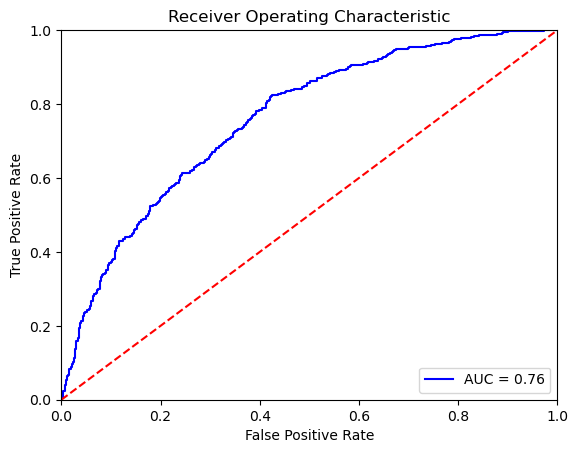

In [86]:
fpr, tpr, thresholds = roc_curve(y_test, logisticModel.predict_proba(X_test)[:,1],
                                         pos_label=1)
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b',
label='AUC = %0.2f'% roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()


In [87]:
random_forest = RandomForestClassifier(min_samples_leaf=100,n_estimators=50,random_state=123)
random_forest.fit(X_train,y_train)
y_pred = random_forest.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,random_forest.predict_proba(X_test)[:,1]))


accuracy:  0.6573333333333333
                    precision    recall  f1-score   support

Non-Defaulted Loan     0.6498    0.8695    0.7438       858
    Defaulted Loan     0.6818    0.3738    0.4829       642

          accuracy                         0.6573      1500
         macro avg     0.6658    0.6216    0.6133      1500
      weighted avg     0.6635    0.6573    0.6321      1500

AUC:  0.7391020194758514


## Remove bc_util, inq_last_6

In [88]:
data.shape

(5000, 40)

In [90]:
# clean and get training/testing data 
temp5 = pd.get_dummies(data[['term','emp_length','home_ownership',
                                  'verification_status','purpose']],dummy_na=True)  #'grade',
subdata5 = data[['loan_amnt','funded_amnt','installment',
                'annual_inc','dti','delinq_2yrs','open_acc','pub_rec', 'cr_hist','revol_bal',
                             'revol_util', 'out_prncp','tot_cur_bal',
                 'pct_tl_nvr_dlq','total_acc','acc_now_delinq','tot_coll_amt'
               ,'loan_length']]   # recoveries , 'total_pymnt', 'default' ,'int_rate', 'funded_amnt_inv',
                                  #'bc_util', 'inq_last_6mths'

In [91]:
X = subdata5.to_numpy()
#X = data.as_matrix(columns=['loan_amnt','funded_amnt','int_rate','installment',
#                            'annual_inc','dti','delinq_2yrs','open_acc','pub_rec',
#                            'cr_hist','revol_bal',
#                            'recoveries',
#                            'revol_util', 'total_pymnt'])

#X = np.concatenate((X,temp.as_matrix()),axis=1)
X = np.concatenate((X,temp5.to_numpy()),axis=1)

#y = data.label.as_matrix()
y = data.label.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

min_max_scaler = preprocessing.MinMaxScaler()
X_train = min_max_scaler.fit_transform(X_train)
X_test = min_max_scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(3500, 56)
(1500, 56)


In [92]:
logisticModel = LogisticRegressionCV(cv=10,penalty='l2',max_iter=2000)
logisticModel.fit(X_train,y_train)

LogisticRegressionCV(cv=10, max_iter=2000)

In [93]:
y_pred = logisticModel.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))

accuracy:  0.672
                    precision    recall  f1-score   support

Non-Defaulted Loan     0.7028    0.7605    0.7306       877
    Defaulted Loan     0.6189    0.5474    0.5809       623

          accuracy                         0.6720      1500
         macro avg     0.6609    0.6539    0.6557      1500
      weighted avg     0.6680    0.6720    0.6684      1500

AUC:  0.7386464508548221


In [94]:
random_forest = RandomForestClassifier(min_samples_leaf=100,n_estimators=50,random_state=123)
random_forest.fit(X_train,y_train)
y_pred = random_forest.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,random_forest.predict_proba(X_test)[:,1]))

accuracy:  0.662
                    precision    recall  f1-score   support

Non-Defaulted Loan     0.6626    0.8597    0.7484       877
    Defaulted Loan     0.6602    0.3836    0.4853       623

          accuracy                         0.6620      1500
         macro avg     0.6614    0.6217    0.6168      1500
      weighted avg     0.6616    0.6620    0.6391      1500

AUC:  0.7348669676831311


## Use only grade

In [ ]:
data.shape

In [ ]:
# clean and get training/testing data 
temp5 = pd.get_dummies(data[['grade']],dummy_na=True)


In [ ]:
X1 = temp5.to_numpy()

y = data.label.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

min_max_scaler = preprocessing.MinMaxScaler()
X_train = min_max_scaler.fit_transform(X_train)
X_test = min_max_scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

In [ ]:
logisticModel = LogisticRegressionCV(cv=10,penalty='l2',max_iter=2000)
logisticModel.fit(X_train,y_train)

In [ ]:
y_pred = logisticModel.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, logisticModel.predict_proba(X_test)[:,1],
                                         pos_label=1)
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b',
label='AUC = %0.2f'% roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
random_forest = RandomForestClassifier(min_samples_leaf=100,n_estimators=50,random_state=123)
random_forest.fit(X_train,y_train)
y_pred = random_forest.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,random_forest.predict_proba(X_test)[:,1]))

## Use Int Rate only

In [ ]:
data.shape

In [ ]:
# clean and get training/testing data 
subdata6 = data[['int_rate']]

In [ ]:
X = subdata6.to_numpy()

y = data.label.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

min_max_scaler = preprocessing.MinMaxScaler()
X_train = min_max_scaler.fit_transform(X_train)
X_test = min_max_scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

In [ ]:
logisticModel = LogisticRegressionCV(cv=10,penalty='l2',max_iter=2000)
logisticModel.fit(X_train,y_train)

In [ ]:
y_pred = logisticModel.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, logisticModel.predict_proba(X_test)[:,1],
                                         pos_label=1)
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b',
label='AUC = %0.2f'% roc_auc_score(y_test,logisticModel.predict_proba(X_test)[:,1]))
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
random_forest = RandomForestClassifier(min_samples_leaf=100,n_estimators=50,random_state=123)
random_forest.fit(X_train,y_train)
y_pred = random_forest.predict(X_test)
print('accuracy: ',accuracy_score(y_test,y_pred))
target_names = ['Non-Defaulted Loan','Defaulted Loan']
print(classification_report(y_test,y_pred,target_names=target_names,digits=4))
print('AUC: ',roc_auc_score(y_test,random_forest.predict_proba(X_test)[:,1]))

## DO NOT USE

In [97]:
# Create the outcome
data["outcome"] = data.loan_status.isin(["Charged Off", "Default"])

In [98]:
data.shape

(5000, 41)

In [99]:
data

,id,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,...,sub_grade,acc_now_delinq,tot_coll_amt,default,loan_length,term_num,weights,label,cr_hist,outcome
281969,23683311,8000.0,8000.0,36 months,16.99,285.19,D,8 years,OWN,35000.0,...,D3,0.0,0.0,1,4.008296,36,3,1,69.980903,True
96742,5030285,24000.0,24000.0,36 months,11.14,787.33,B,10+ years,OWN,124000.0,...,B2,0.0,0.0,0,20.041479,36,1,0,159.970431,False
81458,5799318,28000.0,28000.0,36 months,7.62,872.52,A,1 year,RENT,130000.0,...,A3,0.0,0.0,0,14.029036,36,1,0,98.006119,False
190646,35176218,2200.0,2200.0,36 months,14.99,76.26,C,< 1 year,OWN,11500.0,...,C5,0.0,0.0,1,9.002238,36,3,1,69.028111,True
294385,22443436,12800.0,12800.0,36 months,12.99,431.23,C,10+ years,MORTGAGE,45000.0,...,C1,0.0,0.0,0,20.008624,36,1,0,156.980636,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397586,12294991,9000.0,9000.0,36 months,12.49,301.04,B,2 years,MORTGAGE,50000.0,...,B4,0.0,0.0,0,11.992033,36,1,0,317.049631,False
109853,3922242,5000.0,5000.0,36 months,18.75,182.65,D,< 1 year,RENT,35000.0,...,D3,0.0,0.0,0,26.973860,36,1,0,352.007228,False
114192,3695563,12000.0,12000.0,36 months,15.31,417.81,C,2 years,MORTGAGE,66500.0,...,C2,0.0,0.0,0,36.008953,36,1,0,43.992690,False
291166,12745353,4000.0,4000.0,36 months,8.39,126.07,A,10+ years,OWN,26000.0,...,A5,0.0,0.0,0,17.018830,36,1,0,141.998809,False


In [ ]:
# Create a feature for the length of a person's credit history at the
# time the loan is issued
data['cr_hist'] = (data.issue_d - data.earliest_cr_line) / np.timedelta64(1, 'M')
continuous_features.append('cr_hist')

In [100]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 281969 to 145463
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   5000 non-null   object 
 1   loan_amnt            5000 non-null   float64
 2   funded_amnt          5000 non-null   float64
 3   term                 5000 non-null   object 
 4   int_rate             5000 non-null   float64
 5   installment          5000 non-null   float64
 6   grade                5000 non-null   object 
 7   emp_length           4746 non-null   object 
 8   home_ownership       5000 non-null   object 
 9   annual_inc           5000 non-null   float64
 10  verification_status  5000 non-null   object 
 11  issue_d              5000 non-null   object 
 12  loan_status          5000 non-null   object 
 13  purpose              5000 non-null   object 
 14  dti                  5000 non-null   float64
 15  delinq_2yrs          5000 non-n

In [101]:
# Randomly assign each row to a training and test set. We do this now
# because we will be fitting a variety of models on various time periods,
# and we would like every period to use the *same* training/test split
np.random.seed(default_seed)
data['train'] = np.random.choice([True, False], size = len(data), p = [0.7, 0.3])

In [102]:
# Create a matrix of features and outcomes, with dummies. Record the
# names of the dummies for later use
X_continuous = data[continuous_features].values

X_discrete = pd.get_dummies(data[discrete_features], dummy_na = True, prefix_sep = "::", drop_first = True)
discrete_features_dummies = X_discrete.columns.tolist()
X_discrete = X_discrete.values

X = np.concatenate( (X_continuous, X_discrete), axis = 1 )

y = data.outcome.values

train = data.train.values

In [103]:
continuous_features

['loan_amnt',
 'funded_amnt',
 'installment',
 'annual_inc',
 'dti',
 'revol_bal',
 'delinq_2yrs',
 'open_acc',
 'pub_rec',
 'out_prncp',
 'tot_cur_bal',
 'bc_util',
 'funded_amnt_inv',
 'inq_last_6mths',
 'pct_tl_nvr_dlq',
 'total_acc',
 'acc_now_delinq',
 'tot_coll_amt',
 'int_rate',
 'revol_util']

In [104]:
discrete_features_dummies

['grade::B',
 'grade::C',
 'grade::D',
 'grade::E',
 'grade::F',
 'grade::G',
 'grade::nan',
 'sub_grade::A2',
 'sub_grade::A3',
 'sub_grade::A4',
 'sub_grade::A5',
 'sub_grade::B1',
 'sub_grade::B2',
 'sub_grade::B3',
 'sub_grade::B4',
 'sub_grade::B5',
 'sub_grade::C1',
 'sub_grade::C2',
 'sub_grade::C3',
 'sub_grade::C4',
 'sub_grade::C5',
 'sub_grade::D1',
 'sub_grade::D2',
 'sub_grade::D3',
 'sub_grade::D4',
 'sub_grade::D5',
 'sub_grade::E1',
 'sub_grade::E2',
 'sub_grade::E3',
 'sub_grade::E4',
 'sub_grade::E5',
 'sub_grade::F1',
 'sub_grade::F2',
 'sub_grade::F3',
 'sub_grade::F4',
 'sub_grade::F5',
 'sub_grade::G1',
 'sub_grade::G2',
 'sub_grade::G3',
 'sub_grade::G4',
 'sub_grade::nan',
 'emp_length::10+ years',
 'emp_length::2 years',
 'emp_length::3 years',
 'emp_length::4 years',
 'emp_length::5 years',
 'emp_length::6 years',
 'emp_length::7 years',
 'emp_length::8 years',
 'emp_length::9 years',
 'emp_length::< 1 year',
 'emp_length::nan',
 'purpose::credit_card',
 'purp

In [105]:
X.shape

(5000, 94)

In [106]:
#X.shape ##Orig (240407, 54)

## Prepare functions to fit and evaluate models

In [107]:
def prepare_data(data_subset = np.array([True]*len(data)),
                    n_samples_train = 25000,
                    n_samples_test = 10000,
                    feature_subset = None,
                    date_range_train = (data.issue_d.min(), data.issue_d.max()),
                    date_range_test = (data.issue_d.min(), data.issue_d.max()),
                    random_state = default_seed):
    '''
    This function will prepare the data for classification or regression.
    It expects the following parameters:
      - data_subset: a numpy array with as many entries as rows in the
                     dataset. Each entry should be True if that row
                     should be used, or False if it should be ignored
      - n_samples_train: the total number of samples to be used for training.
                         Will trigger an error if this number is larger than
                         the number of rows available after all filters have
                         been applied
      - n_samples_test: as above for testing
      - feature_subect: A list containing the names of the features to be
                        used in the model. In None, all features in X are
                        used
      - date_range_train: a tuple containing two dates. All rows with loans
                          issued outside of these two dates will be ignored in
                          training
      - date_range_test: as above for testing
      - random_state: the random seed to use when selecting a subset of rows

    Note that this function assumes the data has a "Train" column, and will
    select all training rows from the rows with "True" in that column, and all
    the testing rows from those with a "False" in that column.

    This function returns a dictionary with the following entries
      - X_train: the matrix of training data
      - y_train: the array of training labels
      - train_set: a Boolean vector with as many entries as rows in the data
                  that denotes the rows that were used in the train set
      - X_test: the matrix of testing data
      - y_test: the array of testing labels
      - test_set: a Boolean vector with as many entries as rows in the data
                  that denotes the rows that were used in the test set
    '''

    np.random.seed(random_state)

    # Filter down the data to the required date range, and downsample
    # as required
    filter_train = ( train & (data.issue_d >= date_range_train[0]) &
                            (data.issue_d <= date_range_train[1]) & data_subset ).values
    filter_test = ( (train == False) & (data.issue_d >= date_range_test[0])
                            & (data.issue_d <= date_range_test[1]) & data_subset ).values

    filter_train[ np.random.choice( np.where(filter_train)[0], size = filter_train.sum()
                                   - n_samples_train, replace = False ) ] = False
    filter_test[ np.random.choice( np.where(filter_test)[0], size = filter_test.sum()
                                   - n_samples_test, replace = False ) ] = False

    # Prepare the training and test set
    X_train = X[ filter_train , :]
    X_test = X[ filter_test, :]
    if feature_subset != None:
        cols = [i for i, j in enumerate(continuous_features + discrete_features_dummies)
                                                     if j.split("::")[0] in feature_subset]
        X_train = X_train[ : , cols ]
        X_test = X_test[ : , cols ]

    y_train = y[ filter_train ]
    y_test = y[ filter_test ]

    # Scale the variables
    scaler = preprocessing.MinMaxScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # return training and testing data
    out = {'X_train':X_train, 'y_train':y_train, 'train_set':filter_train,
           'X_test':X_test, 'y_test':y_test, 'test_set':filter_test}

    return out

In [108]:
def fit_classification(model, data_dict,
                          cv_parameters = {},
                          model_name = None,
                          random_state = default_seed,
                          output_to_file = True,
                          print_to_screen = True):
    '''
    This function will fit a classification model to data and print various evaluation
    measures. It expects the following parameters
      - model: an sklearn model object
      - data_dict: the dictionary containing both training and testing data;
                   returned by the prepare_data function
      - cv_parameters: a dictionary of parameters that should be optimized
                       over using cross-validation. Specifically, each named
                       entry in the dictionary should correspond to a parameter,
                       and each element should be a list containing the values
                       to optimize over
      - model_name: the name of the model being fit, for printouts
      - random_state: the random seed to use
      - output_to_file: if the results will be saved to the output file
      - print_to_screen: if the results will be printed on screen

    If the model provided does not have a predict_proba function, we will
    simply print accuracy diagnostics and return.

    If the model provided does have a predict_proba function, we first
    figure out the optimal threshold that maximizes the accuracy and
    print out accuracy diagnostics. We then print an ROC curve, sensitivity/
    specificity curve, and calibration curve.

    This function returns a dictionary with the following entries
      - model: the best fitted model
      - y_pred: predictions for the test set
      - y_pred_probs: probability predictions for the test set, if the model
                      supports them
      - y_pred_score: prediction scores for the test set, if the model does not
                      output probabilities.
    '''

    np.random.seed(random_state)

    # --------------------------
    #   Step 1 - Load the data
    # --------------------------
    X_train = data_dict['X_train']
    y_train = data_dict['y_train']

    X_test = data_dict['X_test']
    y_test = data_dict['y_test']

    filter_train = data_dict['train_set']

    # --------------------------
    #   Step 2 - Fit the model
    # --------------------------

    cv_model = GridSearchCV(model, cv_parameters)

    start_time = time.time()
    cv_model.fit(X_train, y_train)
    end_time = time.time()

    best_model = cv_model.best_estimator_

    if print_to_screen:

        if model_name != None:
            print("=========================================================")
            print("  Model: " + model_name)
            print("=========================================================")

        print("Fit time: " + str(round(end_time - start_time, 2)) + " seconds")
        print("Optimal parameters:")
        print(cv_model.best_params_)
        print("")

    # -------------------------------
    #   Step 3 - Evaluate the model
    # -------------------------------

    # If possible, make probability predictions
    try:
        y_pred_probs = best_model.predict_proba(X_test)[:,1]
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)

        probs_predicted = True
    except:
        probs_predicted = False

    # Make predictions; if we were able to find probabilities, use
    # the threshold that maximizes the accuracy in the training set.
    # If not, just use the learner's predict function
    if probs_predicted:
        y_train_pred_probs = best_model.predict_proba(X_train)[:,1]
        fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_pred_probs)

        true_pos_train = tpr_train*(y_train.sum())
        true_neg_train = (1 - fpr_train) *(1-y_train).sum()

        best_threshold_index = np.argmax(true_pos_train + true_neg_train)
        best_threshold = 1 if best_threshold_index == 0 else thresholds_train[ best_threshold_index ]

        if print_to_screen:
            print("Accuracy-maximizing threshold was: " + str(best_threshold))

        y_pred = (y_pred_probs > best_threshold)
    else:
        y_pred = best_model.predict(X_test)

    if print_to_screen:
        print("Accuracy: ", accuracy_score(y_test, y_pred))
        print(classification_report(y_test, y_pred, target_names =['No default', 'Default'], digits = 4))

    if print_to_screen:
        if probs_predicted:
            plt.figure(figsize = (13, 4.5))
            plt.subplot(2, 2, 1)

            plt.title("ROC Curve (AUC = %0.2f)"% roc_auc_score(y_test, y_pred_probs))
            plt.plot(fpr, tpr, 'b')
            plt.plot([0,1],[0,1],'r--')
            plt.xlim([0,1]); plt.ylim([0,1])
            plt.ylabel('True Positive Rate')
            plt.xlabel('False Positive Rate')

            plt.subplot(2, 2, 3)

            plt.plot(thresholds, tpr, 'b', label = 'Sensitivity')
            plt.plot(thresholds, 1 -fpr, 'r', label = 'Specificity')
            plt.legend(loc = 'lower right')
            plt.xlim([0,1]); plt.ylim([0,1])
            plt.xlabel('Threshold')

            plt.subplot(2, 2, 2)

            fp_0, mpv_0 = calibration_curve(y_test, y_pred_probs, n_bins = 10)
            plt.plot([0,1], [0,1], 'k:', label='Perfectly calibrated')
            plt.plot(mpv_0, fp_0, 's-')
            plt.ylabel('Fraction of Positives')
            plt.xlim([0,1]); plt.ylim([0,1])
            plt.legend(loc ='upper left')

            plt.subplot(2, 2, 4)
            plt.hist(y_pred_probs, range=(0, 1), bins=10, histtype="step", lw=2)
            plt.xlim([0,1]); plt.ylim([0,20000])
            plt.xlabel('Mean Predicted Probability')
            plt.ylabel('Count')

            #plt.tight_layout()
            plt.show()

    # Additional Score Check
    if probs_predicted:
        y_train_score = y_train_pred_probs
    else:
        y_train_score = best_model.decision_function(X_train)

    tau, p_value = kendalltau(y_train_score, data.grade[filter_train])
    if print_to_screen:
        print("")
        print("Similarity to LC grade ranking: ", tau)

    if probs_predicted:
        brier_score = brier_score_loss(y_test, y_pred_probs)
        if print_to_screen:
            print("Brier score:", brier_score)

    # Return the model predictions, and the
    # test set
    # -------------------------------------
    out = {'model':best_model, 'y_pred_labels':y_pred}

    if probs_predicted:
        out.update({'y_pred_probs':y_pred_probs})
    else:
        y_pred_score = best_model.decision_function(X_test)
        out.update({'y_pred_score':y_pred_score})

    # Output results to file
    # ----------------------
    if probs_predicted and output_to_file:
        # Check whether any of the CV parameters are on the edge of
        # the search space
        opt_params_on_edge = find_opt_params_on_edge(cv_model)
        dump_to_output(model_name + "::search_on_edge", opt_params_on_edge)
        if print_to_screen:
            print("Were parameters on edge? : " + str(opt_params_on_edge))

        # Find out how different the scores are for the different values
        # tested for by cross-validation. If they're not too different, then
        # even if the parameters are off the edge of the search grid, we should
        # be ok
        score_variation = find_score_variation(cv_model)
        dump_to_output(model_name + "::score_variation", score_variation)
        if print_to_screen:
            print("Score variations around CV search grid : " + str(score_variation))

        # Print out all the scores
        dump_to_output(model_name + "::all_cv_scores", str(cv_model.cv_results_['mean_test_score']))
        if print_to_screen:
            print( str(cv_model.cv_results_['mean_test_score']) )

        # Dump the AUC to file
        dump_to_output(model_name + "::roc_auc", roc_auc_score(y_test, y_pred_probs) )

    return out


## Step 3 - Baseline models
See how well we do using grade or interest rate only

### Grade

In [109]:
data_dict = prepare_data(feature_subset=['grade'])
grade_only_logistic = LogisticRegression(penalty = 'l2', C=np.inf, solver='lbfgs')

grade_only_logistic = fit_classification(grade_only_logistic,data_dict,
                                         model_name = 'Grade only logistic l2')

ValueError: Negative dimensions are not allowed

In [110]:
data_dict = prepare_data(feature_subset=['int_rate'])
interest_only_logistic = LogisticRegression(penalty = 'l2', C=np.inf, solver='lbfgs')

interest_only_logistic = fit_classification(interest_only_logistic, data_dict,
                                   model_name = 'Interest rate only logistics l2')

ValueError: Negative dimensions are not allowed

## Step 4- Test models without grade or interest rate

In [111]:
final_features = [i for i in discrete_features + continuous_features if i not in ["grade", "int_rate", "installment"]]
data_dict = prepare_data(feature_subset = final_features)

all_features = pd.Series(continuous_features + discrete_features_dummies)
idx = [i for i, j in enumerate(continuous_features + discrete_features_dummies)
                                                     if j.split("::")[0] in final_features]
selected_features = all_features[idx]
selected_features.reset_index(drop=True,inplace=True)

ValueError: Negative dimensions are not allowed

In [112]:
final_features

['sub_grade',
 'emp_length',
 'purpose',
 'term',
 'home_ownership',
 'verification_status',
 'loan_amnt',
 'funded_amnt',
 'annual_inc',
 'dti',
 'revol_bal',
 'delinq_2yrs',
 'open_acc',
 'pub_rec',
 'out_prncp',
 'tot_cur_bal',
 'bc_util',
 'funded_amnt_inv',
 'inq_last_6mths',
 'pct_tl_nvr_dlq',
 'total_acc',
 'acc_now_delinq',
 'tot_coll_amt',
 'revol_util']

### Ridge Classifier

In [113]:
ridge_classifier = RidgeClassifier()
cv_parameters = {"alpha":np.logspace(-4, 4, num = 10)}

ridge_classifier = fit_classification(ridge_classifier, data_dict,
                             cv_parameters = cv_parameters, model_name = "Ridge Classifier")

NameError: name 'data_dict' is not defined

### Naive Bayes

In [ ]:
gnb = GaussianNB()
gnb = fit_classification(gnb, data_dict,
                model_name = "Gaussian Naive Bayes")


### $l_1$ penalized logistic regression
(Takes a couple of minutes)

In [ ]:
#Use version loaded from pickle
l1_logistic = LogisticRegression(penalty = 'l1',solver='liblinear')
cv_parameters = {"C":np.logspace(0, 6, num = 10)}

l1_logistic = fit_classification(l1_logistic, data_dict,
                       cv_parameters = cv_parameters, model_name = "l1 Penalized Logistic Regression")

In [ ]:
## plot top 3 features with the most positive (and negative) weights
top_and_bottom_idx = list(np.argsort(l1_logistic['model'].coef_)[0,:3]) + list(np.argsort(l1_logistic['model'].coef_)[0,-3:])
bplot = pd.Series(l1_logistic['model'].coef_[0,top_and_bottom_idx])
xticks = selected_features[top_and_bottom_idx]
p1 = bplot.plot(kind='bar',rot=-30,ylim=(-2,3))
p1.set_xticklabels(xticks)
plt.show()

### $l_2$ penalized logistic regression

In [ ]:
#Use version loaded from pickle
l2_logistic = LogisticRegression(penalty = 'l2')
cv_parameters = {"C":np.logspace(-4, 4, num = 10)}

l2_logistic = fit_classification(l2_logistic, data_dict,
                       cv_parameters = cv_parameters, model_name = "l2 Penalized Logistic Regression")

In [ ]:
## plot top 3 features with the most positive (and negative) weights
top_and_bottom_idx = list(np.argsort(l2_logistic['model'].coef_)[0,:3]) + list(np.argsort(l2_logistic['model'].coef_)[0,-3:])
bplot = pd.Series(l2_logistic['model'].coef_[0,top_and_bottom_idx])
xticks = selected_features[top_and_bottom_idx]
p1 = bplot.plot(kind='bar',rot=-30,ylim=(-2,3))
p1.set_xticklabels(xticks)
plt.show()

### Decision tree

In [ ]:
#Use version loaded from pickle
decision_tree = DecisionTreeClassifier()
cv_parameters = {'min_samples_leaf':[500,600,700,800,900,1000, 1100, 1200, 1300]}

decision_tree = fit_classification(decision_tree, data_dict,
                         cv_parameters = cv_parameters, model_name = "Decision tree")

In [ ]:
# Visualize the decision tree
# Zooming-in is allowed by double click
!conda install -c conda-forge pygraphviz -y
!conda install python-graphviz pydot -y
import graphviz

dot_data = StringIO()
export_graphviz(decision_tree['model'], out_file=dot_data,
                feature_names=selected_features,filled=True, rounded=True,
                special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

### Random forest
Takes nearly 10 minutes given the large data set!

In [ ]:
#Use version loaded from pickle
random_forest = RandomForestClassifier()
cv_parameters = {'min_samples_leaf':[1, 2, 3, 5, 8, 13, 17, 20, 40], 'n_estimators': [35, 60, 80, 100, 150] }

random_forest_model = fit_classification(random_forest, data_dict,
                                   cv_parameters=cv_parameters, model_name="Random forest")

In [ ]:
## Plot top 6 most significant features
top_idx = list(np.argsort(random_forest_model['model'].feature_importances_)[-6:])
bplot = pd.Series(random_forest_model['model'].feature_importances_[top_idx])
xticks = selected_features[top_idx]
p2 = bplot.plot(kind='bar',rot=-30,ylim=(0,0.2))
p2.set_xticklabels(xticks)
plt.show()

In [ ]:
## A decision tree trained on the scores of random forest
trepin_tree = DecisionTreeClassifier(min_samples_leaf = 100, max_depth = 4)
trepin_tree.fit(random_forest_model['y_pred_probs'].reshape(-1,1),data_dict['y_test'])
dot_data = StringIO()
export_graphviz(trepin_tree, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

### Bagged trees
Takes a very long time for the whole LC data set!!

In [ ]:
# Use saved version
bagged_trees = RandomForestClassifier(max_features = 1.0)
cv_parameters = {'min_samples_leaf':[5, 10, 25, 50, 75, 100, 200], 'n_estimators': [60, 100, 150, 200, 300] }

bagged_trees_model = fit_classification(bagged_trees, data_dict,
                                  cv_parameters=cv_parameters, model_name="Bagged trees")

In [ ]:
## Plot top 6 most significant features
top_idx = list(np.argsort(bagged_trees_model['model'].feature_importances_)[-6:])
bplot = pd.Series(bagged_trees_model['model'].feature_importances_[top_idx])
xticks = selected_features[top_idx]
p2 = bplot.plot(kind='bar',rot=-30,ylim=(0,0.2))
p2.set_xticklabels(xticks)
plt.show()

## Save a "dill" of all your models for later use
If you ran complicated models that has taken considerable time, you can save these models in a dump of the whole session (not just the data) using a version of pickling called "dill" as follows.

In [ ]:
!conda install dill -y
import dill
dill.dump_session('finalweek3.pkl')

#The above command dumps a file in the current directory which you can load later as follows
# import dill
# dill.load_session('week3.pkl')
